# Dataset Characterization

the idea of this notebook is to characterize the dataset only, regarding only structures dft data, maybe composition , ternary plot, and this kind of things.

input: `CuratedBriefSummary.pkl` 

output: plots

In [1]:
from Tools.DatasetTools.Commoms import *
dataset = 'Fe-Mo'  # 'Cr-Co-W'#'Fe-Mo
target_case = 'EF_nmhcp'
components = dataset.split('-')
# sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer  import Featurizer
plt.style.use('default')
#plt.rc('figure', figsize=(15,10))
plt.rc('font', size=22)
plt.rc('text', usetex=True)


In [2]:
BSfile = os.path.join(dataset,'CuratedParsedBriefSummary.pkl' )
BS = pd.read_pickle(BSfile)

In [3]:
BS.shape

(295, 21)

# Population of phases

In [4]:
BS.drop('Fe_pv30.sigma_Fe_pv.FM', inplace=True)

In [5]:
phase_counts = pd.concat([BS['Phase'][BS['Mag']=='NM'].value_counts(), BS['Phase'][BS['Mag']=='FM'].value_counts()], axis=1)

In [6]:
phase_counts.columns=['NM', 'FM']

In [7]:
phase_counts.sum().sum()

294.0

In [8]:
phase_counts

,NM,FM
sigma,32,32.0
C36,32,22.0
mu,31,25.0
R,30,NaN
chi,16,13.0
C14,8,8.0
bcc,6,4.0
fcc,6,5.0
hcp,5,4.0
C15,4,3.0


<AxesSubplot:>

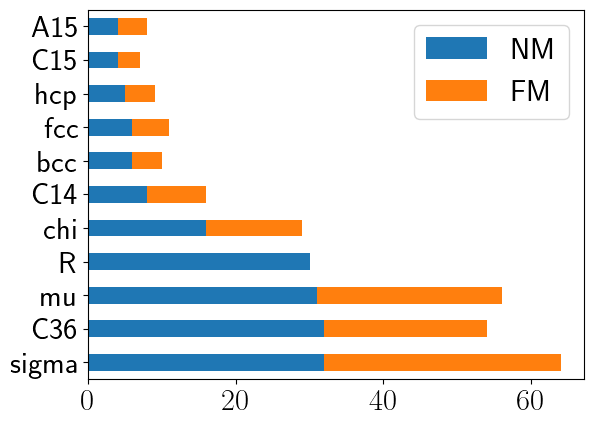

In [9]:
phase_counts.plot.barh(stacked=True)

In [10]:
fw, fh = plt.rcParams['figure.figsize']

In [11]:
simple_tcps = pd.Index(['A15', 'C15', 'C14', 'C36', 'chi', 'sigma', 'mu', 'R'])

In [12]:
simple_tcps.difference(pd.Index(['R']))

Index(['A15', 'C14', 'C15', 'C36', 'chi', 'mu', 'sigma'], dtype='object')

A15 A15
C14 C14
C15 C15
C36 C36
chi chi
mu mu
sigma sigma


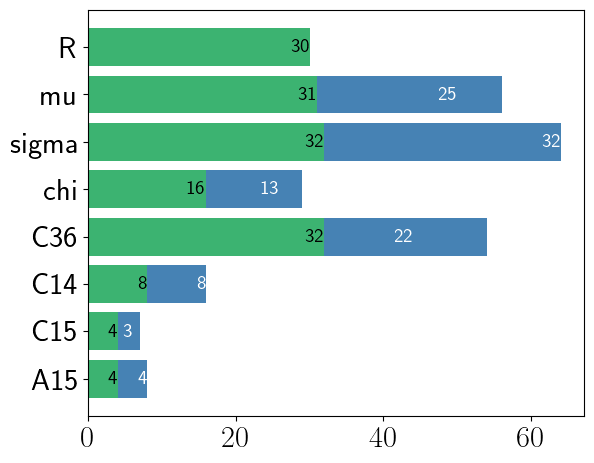

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# phase_counts is your DataFrame with columns ['NM', 'FM']

# Plot stacked horizontal bars
colors = ['mediumseagreen', 'steelblue'] #['#1f77b4', '#ff7f0e']  # You can choose your own colors

fig, ax = plt.subplots(figsize=(fw, fh/10*len(phase_counts)))
ax.barh(simple_tcps, phase_counts['NM'][simple_tcps], color='mediumseagreen', height=.8)
yticks = ax.get_yticks()
for ( phase, count ), y in zip(phase_counts['NM'][simple_tcps].items(), yticks):
    ax.text(count, y, f'{int(count):d}', ha='right', va='center', color='black', fontsize=14)
ax.barh(simple_tcps.difference(['R']), phase_counts['FM'][simple_tcps.difference(['R'])], left=phase_counts['NM'][simple_tcps.difference(['R'])], color='steelblue', height=.8)
for ( phase, count ), y in zip(phase_counts['FM'][simple_tcps.difference(['R'])].items(), yticks):
    print(phase,  phase)
    ax.text(count+phase_counts['FM'][phase], phase, f'{int(count):d}', ha='right', va='center', color='white', fontsize=14)
#ax.set_xlabel(count)

## Remove samples with very little representation

In [18]:
BS = BS[BS['Phase'] != 'delta']

# Extra features 

In [19]:
Features = Featurizer(BS)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


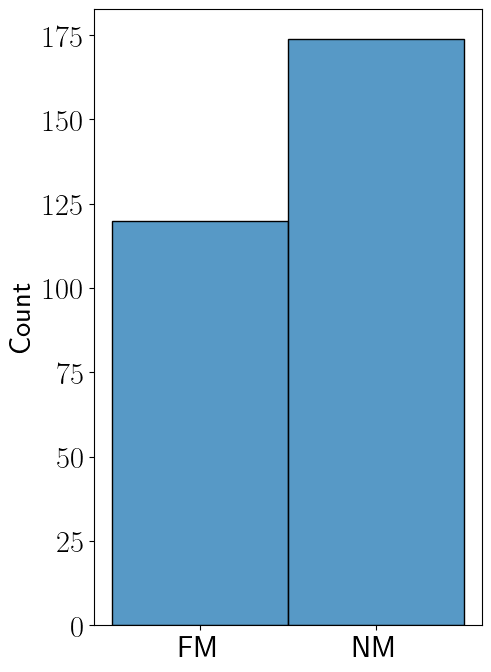

In [20]:
fig, ax = plt.subplots(figsize=(5,8))
sns.histplot(x = Features.Mag, ax=ax)
fig.savefig(f'{dataset}/graphs/{dataset}_FM_NM_counts.eps')

In [21]:
isfm = Features.Mag.str.contains('FM')

In [22]:
fmsamples = BS.index[isfm]

In [23]:
fmsamplesasnm = fmsamples.str.replace('.FM$','.NM')

In [24]:
nmsamples = BS.index[~isfm]

## nm samples without fm counterpart:

In [25]:
nmsamples.difference(fmsamplesasnm)

Index(['Fe_pv10Mo_sv14.C36-ABBAB.NM', 'Fe_pv10Mo_sv14.C36-BABAB.NM',
       'Fe_pv10Mo_sv14.C36-BABBA.NM', 'Fe_pv11Mo_sv2.mu-AABAA.NM',
       'Fe_pv12Mo_sv12.C36-AAABB.NM', 'Fe_pv12Mo_sv17.chi-BBAB.NM',
       'Fe_pv14Mo_sv10.C36-AABAB.NM', 'Fe_pv14Mo_sv10.C36-AABBA.NM',
       'Fe_pv14Mo_sv10.C36-ABAAB.NM', 'Fe_pv14Mo_sv10.C36-BAABA.NM',
       'Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM', 'Fe_pv16Mo_sv13.chi-BAAB.NM',
       'Fe_pv17Mo_sv12.chi-AAAB.NM', 'Fe_pv18Mo_sv6.C36-AAABA.NM',
       'Fe_pv19Mo_sv34.R-ABAABABBBBB.NM', 'Fe_pv1Mo_sv1.L10-NiAl-AB.NM',
       'Fe_pv1Mo_sv3.D03-AB3.NM', 'Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM',
       'Fe_pv21Mo_sv32.R-AAAAABBBBBB.NM', 'Fe_pv21Mo_sv32.R-AAABAABBBBB.NM',
       'Fe_pv23Mo_sv30.R-AABABABABAB.NM', 'Fe_pv24Mo_sv29.R-BBAAAABBBBB.NM',
       'Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM', 'Fe_pv27Mo_sv26.R-AAAAABBABBB.NM',
       'Fe_pv27Mo_sv26.R-AAAABABABBB.NM', 'Fe_pv29Mo_sv24.R-AAAABABABAB.NM',
       'Fe_pv2Mo_sv2.B32-AB.NM', 'Fe_pv2Mo_sv4.C15-AB2.NM',
       'Fe

## fm samples as without nm counterpart:

In [25]:
fmsamplesasnm.difference(nmsamples)

Index(['Fe_pv1.bcc.FM', 'Fe_pv1.fcc.FM', 'Fe_pv10Mo_sv14.C36-ABBBA.FM',
       'Fe_pv10Mo_sv14.C36-BBAAB.FM', 'Fe_pv10Mo_sv14.C36-BBABA.FM',
       'Fe_pv10Mo_sv2.C14-ABA.FM', 'Fe_pv10Mo_sv20.sigma-ABABB.FM',
       'Fe_pv10Mo_sv20.sigma-ABBAB.FM', 'Fe_pv10Mo_sv20.sigma-ABBBA.FM',
       'Fe_pv10Mo_sv3.mu-BAAAB.FM',
       ...
       'Mo_sv12.C14.FM', 'Mo_sv13.mu.FM', 'Mo_sv2.hcp.FM', 'Mo_sv24.C36.FM',
       'Mo_sv29.chi.FM', 'Mo_sv30.sigma.FM', 'Mo_sv4.fcc-cubic.FM',
       'Mo_sv53.R.FM', 'Mo_sv6.C15.FM', 'Mo_sv8.A15.FM'],
      dtype='object', length=118)

# Distribution of Target Variables 

## total energy

In [26]:
targets = {'E0':r'$E_0$', 'B0':r'$B_0$', 'V0':r'$V_0$'}

some obvious outliers:

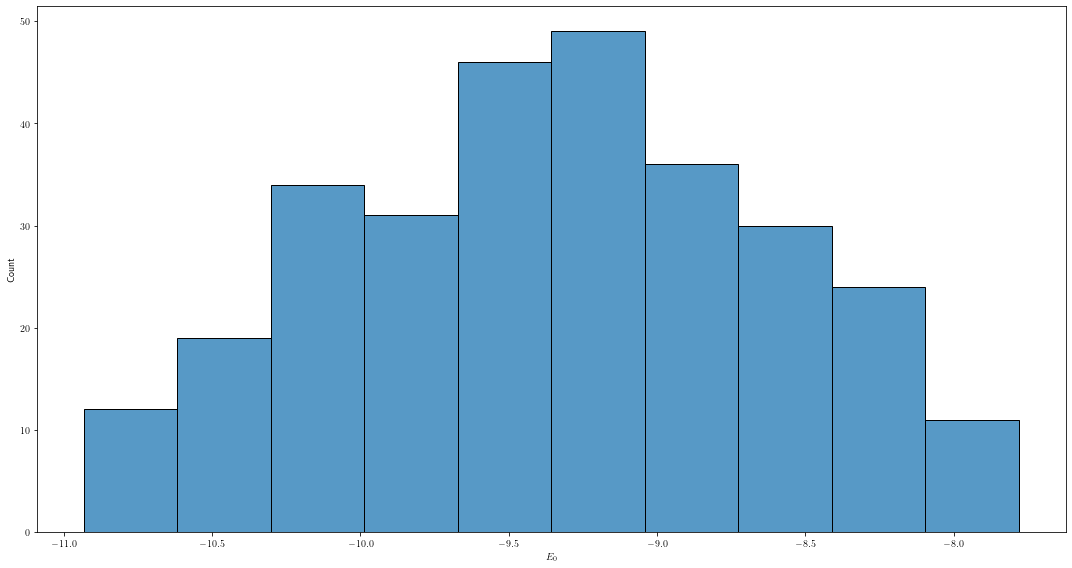

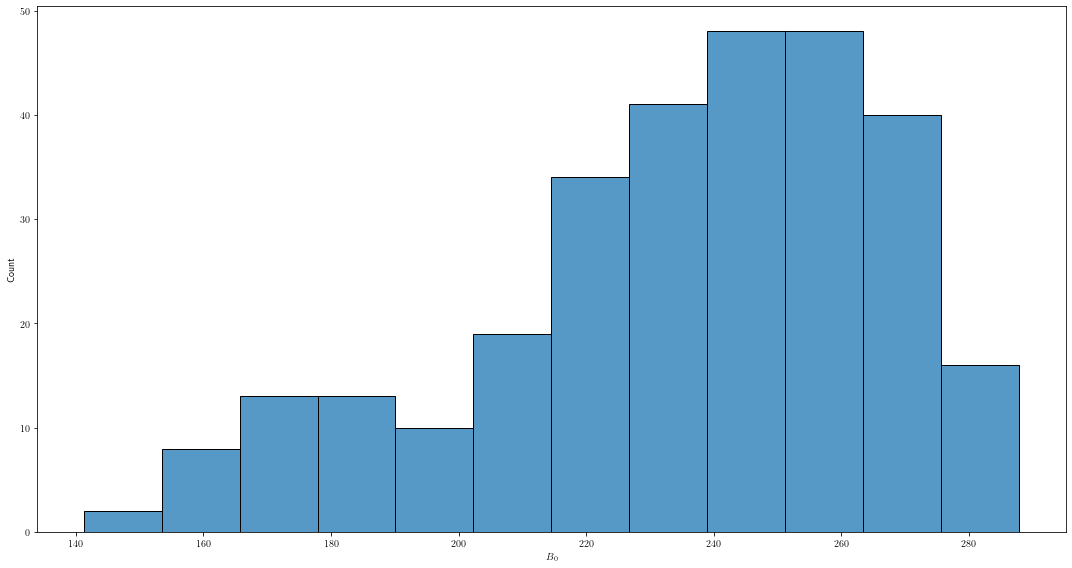

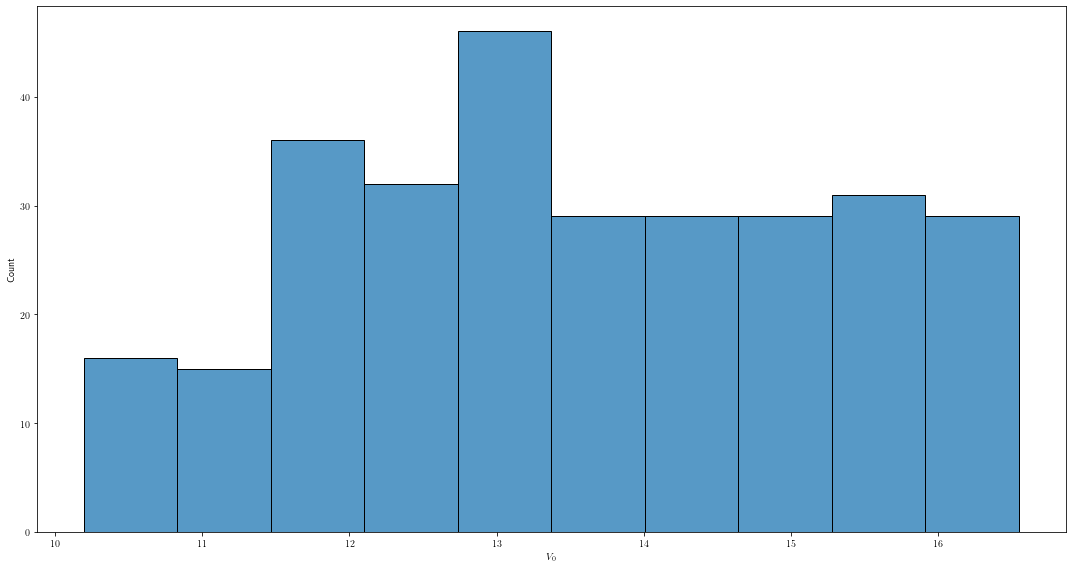

In [27]:
for target, label in targets.items():
    fig, ax = plt.subplots(figsize = (15,8 ))
    sns.histplot(x = BS[target], ax = ax)
    ax.set_xlabel(label)
    fig.tight_layout()

# General correlation

In [28]:
BS.sort_values(by='B0', inplace=True)

In [29]:
targets['E0'] = '$E_0$'

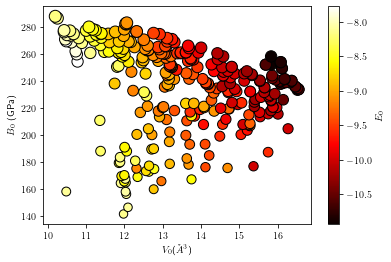

In [32]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.B0, c=BS['E0'], marker = 'o' , s = BS.B0/2, cmap='hot', edgecolor='k')
cbar = plt.colorbar()
plt.ylabel(targets['B0']+' (GPa)')
plt.xlabel(targets['V0']+'($\\AA^3$)')
cbar.set_label(targets['E0'])

# Pair Plots

In [33]:
ToPlot = BS[list(targets.keys())]
ToPlot.columns = list(targets.values()) 

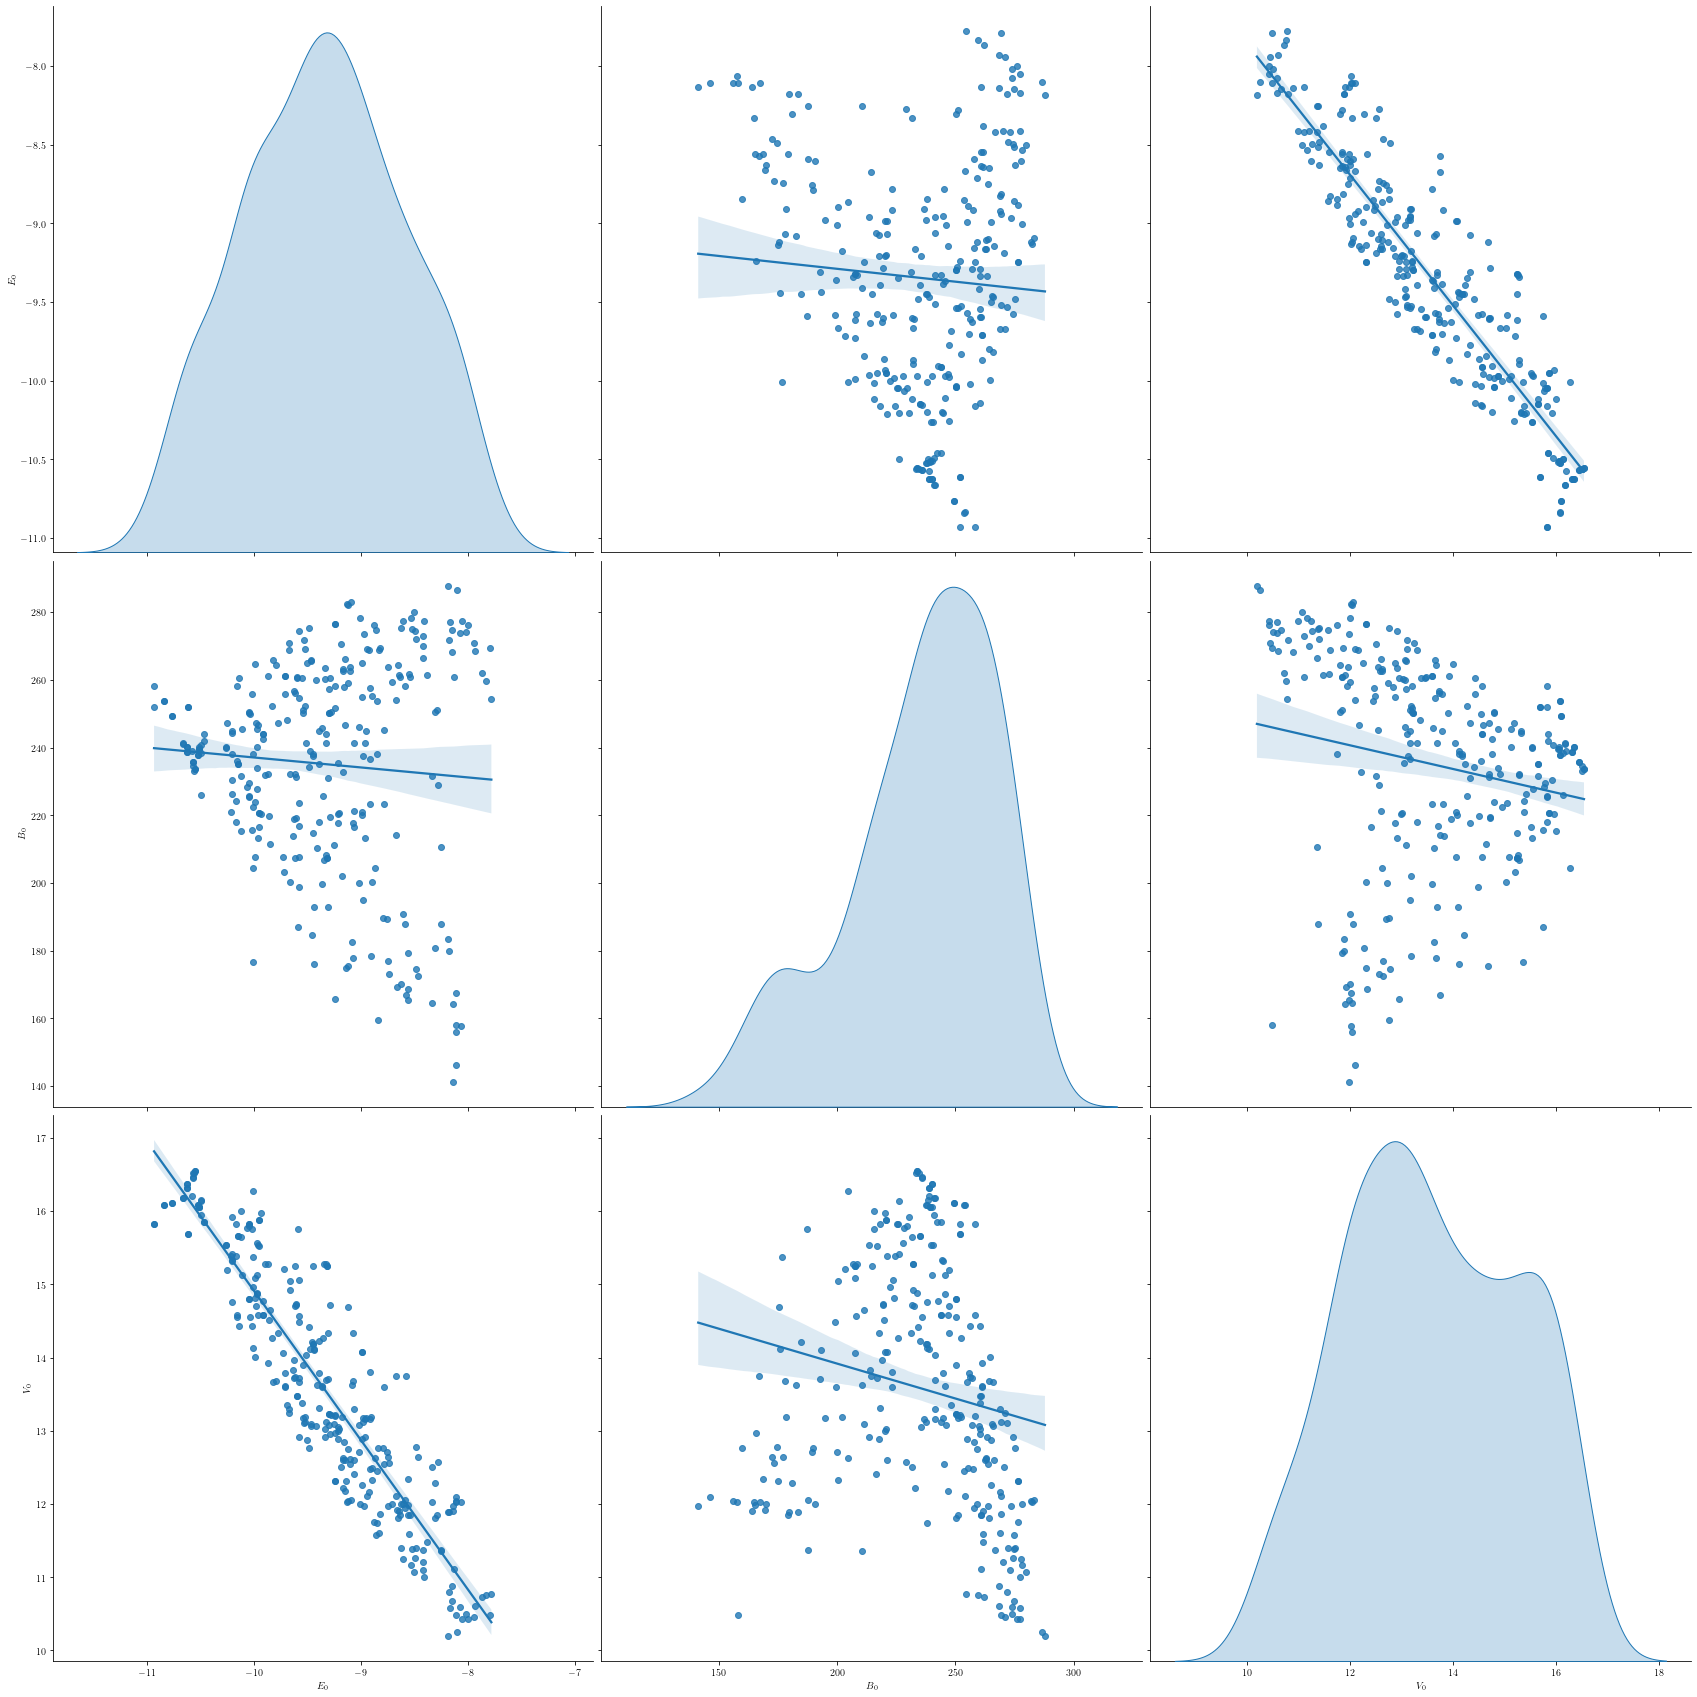

In [34]:
axis_grid = sns.pairplot(ToPlot, diag_kind = 'kde', kind='reg', height=8)
#, hue='Phase', x_vars=list(targets.values()), y_vars=list(targets.values()), )

# Magnetic vs Non Magnetic

EFFM = BS[target_case][Features.Mag == 'FM']

EFNMfcc = BS[target_case][Features.Mag == 'NM']

EFNMhcp = BS[target_case][Features.Mag == 'NM']

EFFM.index = EFFM.index.str.replace('.FM', '')

EFNMhcp.index = EFNMhcp.index.str.replace('.NM', '')

EFNMhcp.index = EFNMhcp.index.str.replace('.NM', '')

DE_mag  = EFNMhcp - EFFM 

DE_mag[ abs(DE_mag > 0.1)]

DE_mag[DE_mag < 0 ]

ax = sns.histplot(BS[BS.index.str.contains('NM$')]['EF_nmfcc'], color = 'purple', label = "NM fcc ground state")
ax = sns.histplot(BS[BS.index.str.contains('NM$')]['EF_nmhcp'], color='orange', label ='NM hcp ground state')
ax.legend()

x = [-0.1, 0.8] 
y = [-0.1, 0.8]
ax  = sns.scatterplot(EFFM, EFNMhcp, label=target_case)
ax  = sns.scatterplot(EFFM, EFNMfcc, label=target_case, ax=ax, color='purple', size = 20)
ax.plot(x,y, '--k')
ax.set_xlabel(r'$\Delta E _f $ FM  eV/atom')
ax.set_ylabel(r'$\Delta E _f $ NM  eV/atom ')
big_difference = DE_mag[DE_mag.abs()>0.18].index#.index[0]
for bigdifindex in big_difference:
    xy = (EFFM[bigdifindex], EFNMhcp[bigdifindex])
    xytext = (EFFM[bigdifindex],  EFNMhcp[bigdifindex]*1.1)
    ax.annotate(bigdifindex, xy , xytext = xytext, arrowprops={'width': 5, })

BIGDIF_FM = BS.filter(regex='E0|atom_').loc[big_difference+'.FM']

BIGDIF_NM = BS.filter(regex='E0|atom_').loc[big_difference+'.NM']

pd.concat([BIGDIF_FM, BIGDIF_NM], axis = 0)

Features.get_ground_states_energies()

EREF_FM = BS[BS.index.str.contains('FM$', regex=True) & (BS['nelem'] == 1) & (BS['atom_A'] == 'Fe_pv') ][['E0']].sort_values(by='E0').iloc[0]

EREF_FM

BIGDIF_FM['E0'] - EREF_FM['E0']

EREF_NM = BS[BS.index.str.contains('NM$', regex=True) & (BS['nelem'] == 1) & (BS['atom_A'] == 'Fe_pv') ][['E0', 'num_atom_A', 'num_atoms']].sort_values(by='E0').iloc[0]

EREF_NM

BIGDIF_NM['E0'] - EREF_NM['E0']

BS.columns



In [44]:
BS.query('Phase == "R"')[['Fe_pv','Mo_sv','B0', 'V0','EF_nmhcp']].sort_values(by = 'Mo_sv')

KeyError: "['EF_nmhcp'] not in index"